## **Lo que van a encontrar en este notebook**

Tenemos dos metas:

1. Ver ejemplos de conjuntos de datos, y como PCA (Principal Component Analysis) puede ser utilizado para visualizarlos.

2. En el camino, aprenderemos a manipular Python de manera muy basica.

Completar las actividades marcadas con **Hacer** o **Tu Respuesta**. Sugiero leer atentamente el codigo y los comentarios para tener una idea de que esta pasando.

---

### 1. Importar librerias

**Hacer:** Importa ``numpy`` y llamalo ``np``, que es la practica estandard.
Numpy es una libreria (i.e., una coleccion de funciones, constantes, etc. Ver https://www.geeksforgeeks.org/libraries-in-python/) para operaciones con vectores y matrices (llamados numpy arrays). Ver: https://numpy.org/

Lee el contenido de la celda siguiente. Las lineas que empiezan con el numeral (#) son comentarios, los cuales no seran evaluados, y el resto es el codigo que si correra.

In [1]:
# Para correr esta celda, da click en cualquier lugar de ella (para seleccionarla) y:
#   opcion 1 (mouse): Da click en el boton Run (el triangulo negro)
#   opcion 2 (teclado): Oprime Ctrl + Enter (Windows, Linux) | Command + Enter (Mac)

import numpy as np

Si todo salio bien, el ``[ ]:`` en la parte superior izquierda de la celda anterior sera reemplazado por ``[ 1 ]:``.

Si corres la celda de nuevo, el contador `` 1 `` se incrementara. Despues de esto, numpy estara disponible para usar en este notebook.

**Hacer:** Correr la celda siguiente.

In [2]:
x = np.arange(7)
print('El numpy array x es igual a', x)
print('La suma de sus entradas es:', np.sum(x))

El numpy array x es igual a [0 1 2 3 4 5 6]
La suma de sus entradas es: 21


Si todo salio bien, podras ver el numpy array ``x`` y la suma de sus entradas.

**Importante:** Si te sale el error:  

``NameError: name 'np' is not defined``

es porque no importaste numpy (as np) antes de usarlo. Ve a las celdas anteriores y correlas.

_Leccion:_ El orden en el que se corren las celdas de un Juptyer notebook importa.

---

### 2. Para graficar

``matplotlib`` es la libreria estandard de Python para graficar y visualizar  (https://matplotlib.org/).
La celda que sigue importa una porcion de matplotlib (i.e., un modulo) llamado ``pyplot``.

In [3]:
# De la libreria matplotlib, importamos el modulo pyplot para graficar. Lo llamaremos plt, que es lo estandard
from matplotlib import pyplot as plt

La siguiente celda genera un conjunto de datos usando numpy, y luego los grafica usando matplotlib.

**Hacer:** Corre la siguiente celda

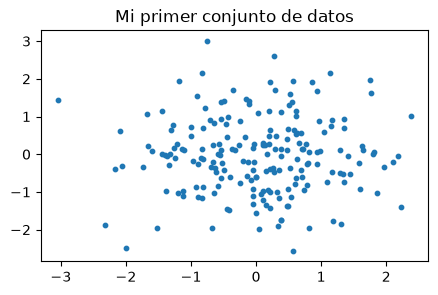

In [4]:
# Generar un conjunto de datos en R^2 con 200 puntos

n_data = 200
X = np.random.randn(n_data, 2)

# Graficar los datos
plt.figure(figsize=(5, 3))
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.title('Mi primer conjunto de datos')
plt.show()

---

### 3. Ejemplo - digitos

``scikit-learn`` (ver https://scikit-learn.org/stable/) es una libreria estandard de Python para ciencia de datos. Trae conjuntos de datos populares, funcionalidad para graficar, analisis de regresion, reduccion de dimension (e.g., PCA, MDS, ISOMAP, etc) y mucho mas.

**Hacer:** Lee y corre las celdas que siguen para cargar e inspeccionar los datos de digitos (https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits)

In [5]:
# De el modulo de datasets de scikit learn, importar la funcion digits
from sklearn.datasets import load_digits

# Importar el conjunto de datos de digitos
digits = load_digits()

# Separamos los datos y sus etiquetas (i.e., el numero)
X = digits.data
etiquetas = digits.target

In [6]:
# Los datos X son una matriz numpy de 1,797 filas por 64 columnas. Cada imagen (8 x 8 pixeles) es una fila de X.
X.shape

(1797, 64)

**Hacer:** Cuantas imagenes hay en el conjunto de datos de digitos? Si cada imagen se piensa como un vector en $\mathbb{R}^n$, cual es el valor de $n$?

**Tu respuesta:** Hay **1797 imagenes** (las filas de `X`). Como cada imagen es de 8 x 8 pixeles, al aplanarla se obtiene un vector con 8 x 8 = **64** entradas, es decir $n = 64$ (las columnas de `X`). Por eso `X.shape` es `(1797, 64)`.

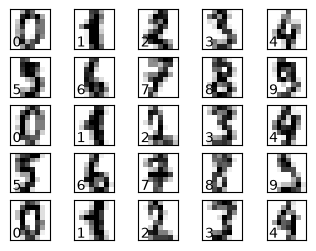

<Figure size 640x480 with 0 Axes>

In [7]:
# Veamos las primeras 25 imagenes con sus etiquetas correspondientes

fig = plt.figure(figsize=(4, 3))

for i in range(25):
    ax = fig.add_subplot(5, 5, i + 1, xticks=[], yticks=[])
    ax.imshow(digits.images[i], cmap=plt.cm.binary)
    ax.text(0, 7, str(etiquetas[i]))

_ = plt.figure()

---

Ahora utilizaremos Analisis de Componentes Principales (PCA, ver https://en.wikipedia.org/wiki/Principal_component_analysis) , para proyectar y visualizar los datos en $\mathbb{R}^2$.

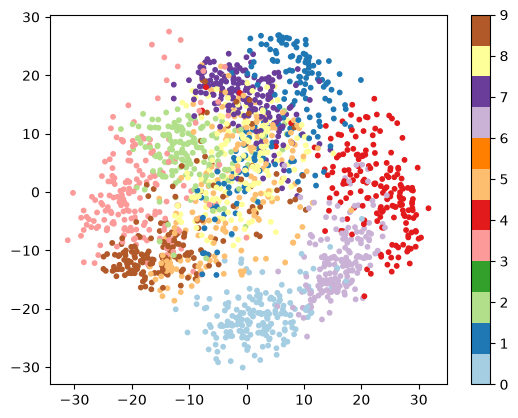

In [8]:
# De scikit learn, importar el modulo de Analisis de Componentes Principales
from sklearn.decomposition import PCA

# Construimos un objeto PCA con 2 dimensiones
pca = PCA(n_components=2)

# Calculamos la proyeccion de los datos en sus primeras 2 componentes principales
X_pca_2d = pca.fit_transform(X)

# Graficamos la proyeccion PCA 2D de los datos, coloreados por sus etiquetas
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], s= 10, c=etiquetas, cmap="Paired");
plt.colorbar();

**Hacer:** Dada la figura de arriba, que digito seria el mas facil de separar/clasificar del resto?

**Tu respuesta:** El digito **0**. En la proyeccion PCA 2D forma el grupo mas compacto y alejado del resto (es el que menos se solapa con los demas colores). Midiendo la separacion como la distancia del centroide de cada digito a su vecino mas cercano dividida por la dispersion propia del grupo, el 0 obtiene el valor mas alto (~2.9), seguido por el 6 y el 4.

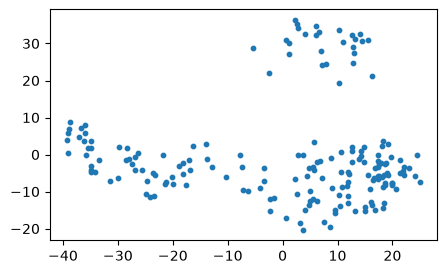

In [9]:
# Ahora vamos a analizar las imagenes de un solo digito
# En particular, encontramos solo las imagenes que tenga etiqueta '1'
indices = np.where(etiquetas==1)[0]

# PCA 2D solo para los  1's
pca = PCA(n_components=2)
proj = pca.fit_transform(X[indices])

# Graficamos la proyeccion PCA 2D de los 1's
plt.figure(figsize=(5, 3))
plt.scatter(proj[:,0],proj[:,1], s=10)
plt.show()

**Hacer:** Los datos parecen dividirse en grupos diferentes. Cuantos Tipos de 1's parece haber en los datos?

**Tu respuesta:** A partir de la proyeccion PCA 2D de solo los 1's, la nube parece separarse en aproximadamente **2 o 3 grupos** distintos.

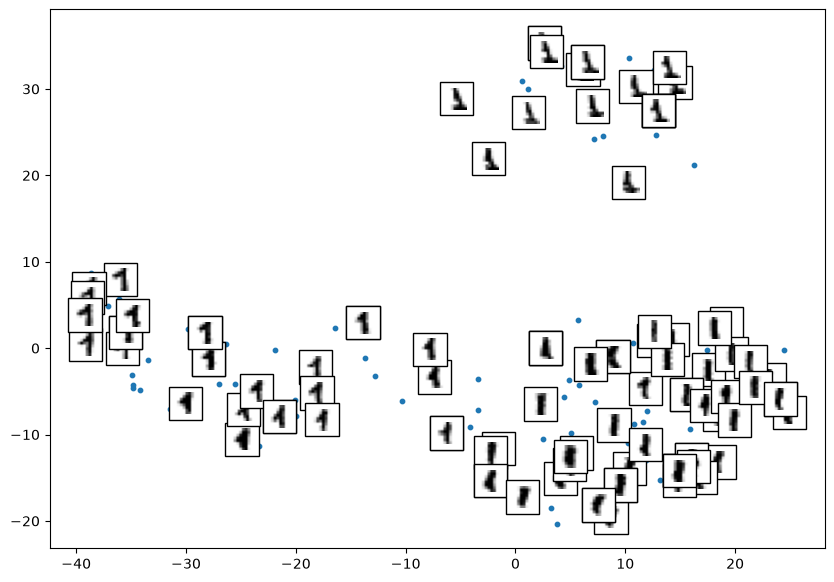

In [10]:
# para tener una mejor idea de cuales son los 1's que aparecen en los datos,
# vamos a visualizar algunas de las imagenes (en muestra):

muestra  = np.random.choice(len(indices), 100)

from matplotlib.offsetbox import OffsetImage, AnnotationBbox

fig, ax = plt.subplots(figsize=(10,7))
ax.scatter(proj[:,0], proj[:,1], s=10)

for x0, y0, im in zip(proj[muestra,0], proj[muestra,1],digits["images"][indices][muestra]):
    ab = AnnotationBbox(OffsetImage(im, cmap='binary',zoom=2), (x0, y0))
    ax.add_artist(ab)

**Hacer:** Dada la grafica de arriba, cuantos tipos de 1's hay en el conjunto de datos? Tu respuesta ha cambiado con respecto a la celda anterior?

**Tu respuesta:** Al superponer las imagenes sobre la proyeccion se distinguen alrededor de **3 tipos de 1's** segun su estilo de escritura: (1) el trazo vertical simple, (2) el 1 inclinado / con bandera o gancho en la parte superior, y (3) el 1 con una base o serifa horizontal en la parte inferior. Esto afina la respuesta de la celda anterior: ver las imagenes reales permite interpretar los grupos del PCA y confirmar que son distintas formas de escribir el '1'. (Un agrupamiento k-means sobre la proyeccion tambien muestra que el mayor salto de calidad ocurre al pasar de 2 a 3 grupos.)